In [10]:
! pip install category_encoders



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
! pip install xgboost


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


<h1>Treinando uma regressão linear aplicando regularização ElasticNet</h1>
<h5>Em seguida, comparamos com o resultado de outros modelo </h5>

In [1]:
import pandas as pd 
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import StratifiedKFold
from category_encoders import TargetEncoder

In [12]:
df = pd.read_csv('../regressao_linear/archive/Salary Data.csv')
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [13]:
nulos = df.isnull().sum()
nulos

Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64

In [14]:
df = df.dropna()
df

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0
...,...,...,...,...,...,...
370,35.0,Female,Bachelor's,Senior Marketing Analyst,8.0,85000.0
371,43.0,Male,Master's,Director of Operations,19.0,170000.0
372,29.0,Female,Bachelor's,Junior Project Manager,2.0,40000.0
373,34.0,Male,Bachelor's,Senior Operations Coordinator,7.0,90000.0


In [15]:
df['Job Title'].value_counts()


Job Title
Director of Marketing             12
Director of Operations            11
Senior Business Analyst           10
Senior Marketing Manager           9
Senior Marketing Analyst           9
                                  ..
Junior Social Media Specialist     1
Junior Operations Coordinator      1
Senior HR Specialist               1
Director of HR                     1
Junior Financial Advisor           1
Name: count, Length: 174, dtype: int64

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def regression_report(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    print("--- Regression Report ---")
    print(f"MAE:  R$ {mae:.2f}")
    print(f"RMSE: R$ {rmse:.2f}")
    print(f"R²:   {r2:.4f}")
    print("-------------------------")

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold = 1
for train_index, val_index in skf.split(df, df['Salary']):
    # Divisão dos dados do Fold
    X_train, X_val = df.iloc[train_index].drop(['Salary'], axis=1), df.iloc[val_index].drop(['Salary'], axis=1)
    y_train, y_val = df.iloc[train_index]['Salary'], df.iloc[val_index]['Salary']

    # 1. Instanciar o encoder dentro do loop
    encoder = TargetEncoder(cols=[ 'Gender', 'Education Level', 'Job Title'], smoothing=10.0)

    # 2. Fit no treino e transform no treino e na validação
    X_train_encoded = encoder.fit_transform(X_train, y_train)
    X_val_encoded = encoder.transform(X_val)

    model = ElasticNet(alpha=0.1)
    model.fit(X_train_encoded, y_train)
    y_pred = model.predict(X_val_encoded)

    regression_report(y_val, y_pred)
    
    print(f"Processando Fold {fold}...")
    fold += 1

In [ ]:


# Criamos faixas de salário para garantir que cada fold tenha salários variados
df['salary_bins'] = pd.qcut(df['Salary'], q=5, labels=False)
X = df.drop(['Salary', 'salary_bins'], axis=1)
y = df['Salary']

# 2. Lista completa de modelos para o duelo
modelos_para_testar = [
    ('Linear Regression - Ridge', Ridge(alpha=1.0)),
    ('Random Forest', RandomForestRegressor(n_estimators=100, random_state=42)),
    ('XGBoost', XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)),
    ('SVR', SVR(kernel='rbf', C=1000, epsilon=0.1, gamma=0.1)),
    ('KNN', KNeighborsRegressor(n_neighbors=5))
]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. Loop de Execução e Avaliação
print(f"{'Modelo':<20} | {'MAE':<12} | {'RMSE':<12} | {'R²':<10}")
print("-" * 65)

for nome, modelo in modelos_para_testar:
    mae_folds, rmse_folds, r2_folds = [], [], []
    
    for train_idx, val_idx in skf.split(df, df['salary_bins']):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        # Pipeline Robust
        pipeline = Pipeline([
            ('encoder', TargetEncoder(cols=[ 'Gender', 'Education Level', 'Job Title'], smoothing=10.0)),
            ('scaler', StandardScaler()),
            ('regressor', modelo)
        ])

        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_val)

        mae_folds.append(mean_absolute_error(y_val, y_pred))
        rmse_folds.append(np.sqrt(mean_squared_error(y_val, y_pred)))
        r2_folds.append(r2_score(y_val, y_pred))

    # Printando os resultados de forma organizada
    print(f"{nome:<20} | R$ {np.mean(mae_folds):>9.2f} | R$ {np.mean(rmse_folds):>9.2f} | {np.mean(r2_folds):>8.4f}")

Modelo               | MAE          | RMSE         | R²        
-----------------------------------------------------------------
Linear Regression - Ridge | R$  13002.68 | R$  18223.58 |   0.8552
Random Forest        | R$  17713.46 | R$  27729.07 |   0.6653
XGBoost              | R$  17812.57 | R$  28281.75 |   0.6516
SVR                  | R$  16087.95 | R$  21042.49 |   0.8078
KNN                  | R$  11357.68 | R$  16889.97 |   0.8747


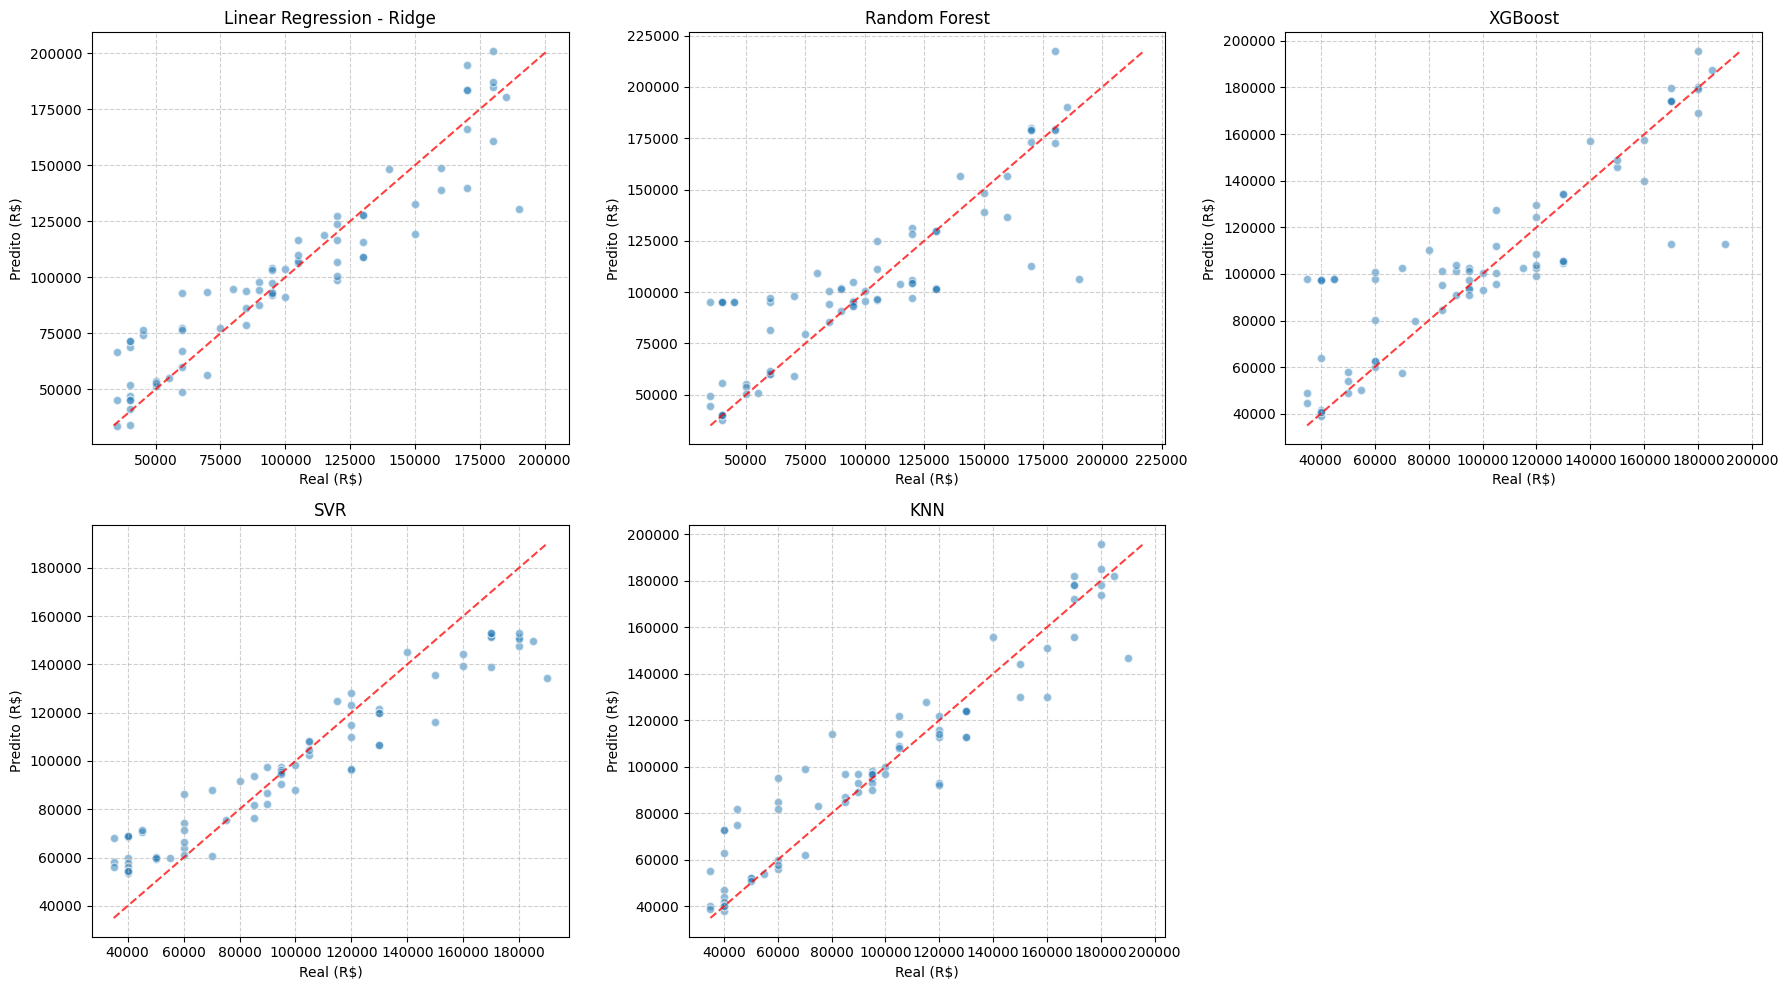

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurando a figura para os 5 modelos (2 linhas, 3 colunas)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (nome, modelo) in enumerate(modelos_para_testar):
    # Usando um split simples para o gráfico (apenas para visualização rápida)
    pipeline = Pipeline([
        ('encoder', TargetEncoder(cols=[ 'Gender', 'Education Level', 'Job Title'], smoothing=10.0)),
        ('scaler', StandardScaler()),
        ('regressor', modelo)
    ])
    
    # Treinando no treino e predizendo na validação do último fold
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_val)
    
    # Plotando no subplot correspondente
    ax = axes[i]
    ax.scatter(y_val, y_pred, alpha=0.5, edgecolors='w')
    
    # Linha diagonal de 45 graus (Onde o modelo acertaria 100%)
    lims = [np.min([y_val.min(), y_pred.min()]), np.max([y_val.max(), y_pred.max()])]
    ax.plot(lims, lims, 'r--', alpha=0.75, zorder=3)
    
    ax.set_title(f'{nome}')
    ax.set_xlabel('Real (R$)')
    ax.set_ylabel('Predito (R$)')
    ax.grid(True, linestyle='--', alpha=0.6)

# Remove o último subplot vazio (já que temos 5 modelos e 6 espaços)
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()